In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2020 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define evaluation SNR and MSE


In [ ]:
import numpy as np

def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    sigma_n = np.var(err)
    sigma_s = np.var(actu)
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

# Perform 2D-DWT Compression on Peper Image using Threholds

Load Dog Image

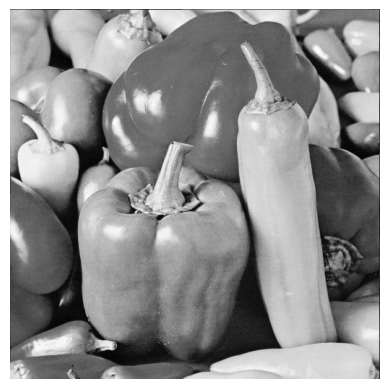

In [ ]:
import numpy as np

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load Peper image
import scipy.io as sio
img = sio.loadmat(work_path + 'Data/peppers.mat')['peppers']

# plot image
import matplotlib.pyplot as plt
plt.imshow(img, cmap='gray')
plt.axis('off');

SNR: 8.61
MSE: 401.36


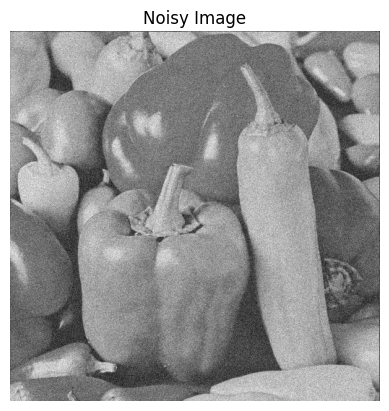

In [ ]:
# add Gaussian noise
noise = np.random.normal(0, 20, img.shape)
img_n = img + noise

# print SNR and MSE
print('SNR:', np.round(snr_dB(img, img_n),2))
print('MSE:', np.round(MSE(img, img_n), 2))

# plot image
import matplotlib.pyplot as plt
plt.title('Noisy Image')
plt.imshow(img_n, cmap='gray')
plt.axis('off');


Perform 2D-DWT

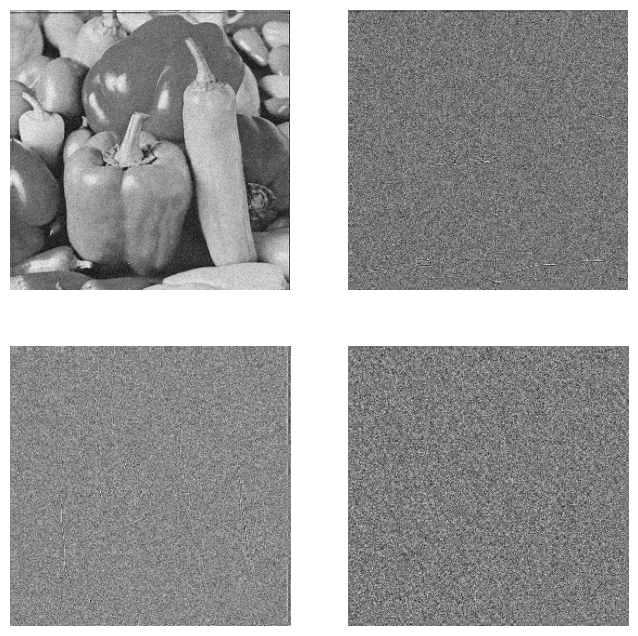

In [ ]:
import pywt
import cv2
import numpy as np

# take 2D-DWT
coeffs = pywt.dwt2(img_n, 'db4', axes=(0,1))
cA, (cH, cV, cD) = coeffs
coeffs_list = [cA, cH, cV, cD]

fig, ax = plt.subplots(2, 2, figsize=(8, 8))
# fig.suptitle("2D-DWT", fontsize=16)
for i in range(2):
    for j in range(2):
        norm_image = cv2.normalize(coeffs_list[i*2+j], None,
                                   alpha = 0,
                                   beta = 255,
                                   norm_type = cv2.NORM_MINMAX,
                                   dtype = cv2.CV_32F).astype('int')
        ax[i,j].imshow(norm_image, cmap='gray')
        ax[i,j].axis('off')


 Plot the histograms of each detail

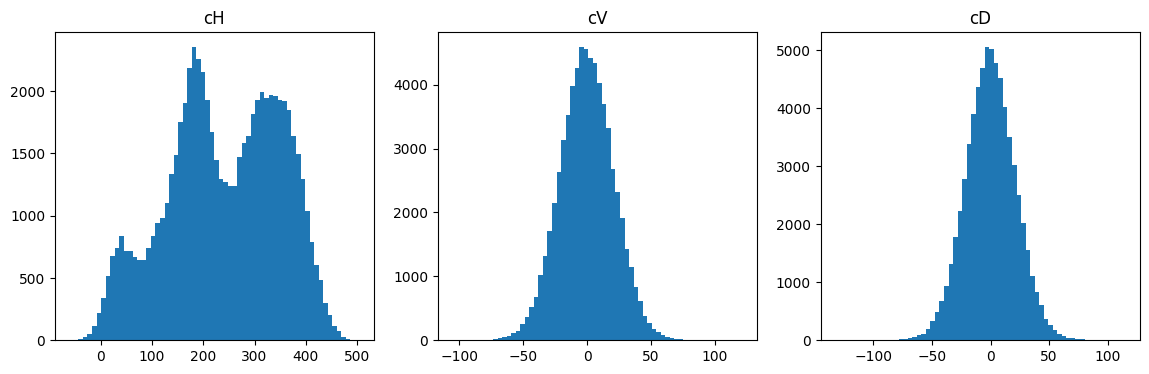

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
titles = ["cH", "cV","cD",]
for i in range(3):
    ax[i].hist(coeffs_list[i].ravel(), bins=64)
    ax[i].set_title(titles[i])


Thresolding

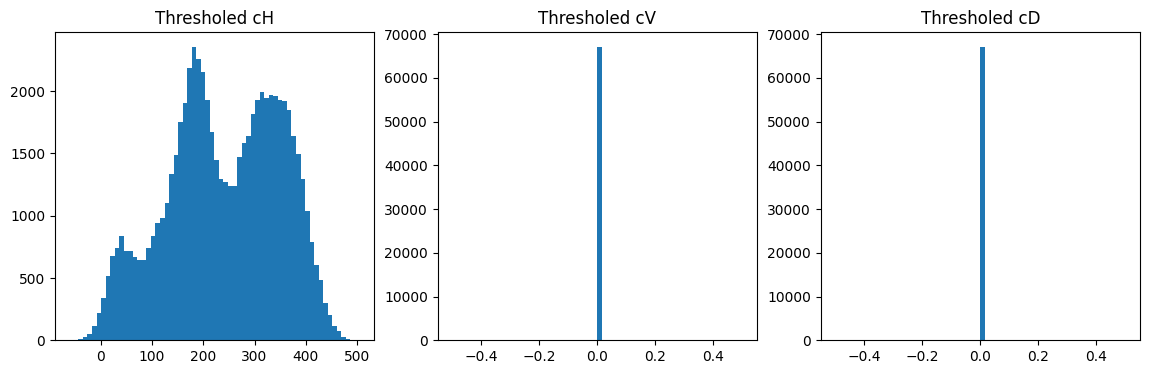

In [ ]:
# Thresolding
cH[cH<150]=0
cV[cV<150]=0
cD[cD<150]=0
coeffs_list = [cA, cH, cV, cD]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
titles = ["Thresholed cH", "Thresholed cV","Thresholed cD",]
for i in range(3):
    ax[i].hist(coeffs_list[i].ravel(), bins=64)
    ax[i].set_title(titles[i])


Inverse 2D-DWT

SNR: 13.05
MSE: 88.26


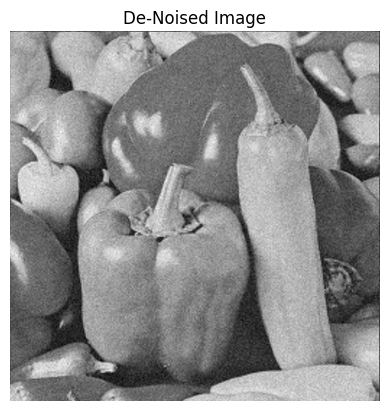

In [ ]:
# take 2D-iDWT
img_idwt = pywt.idwt2(coeffs, 'db4', axes=(0,1))

norm_image = cv2.normalize(img_idwt, None,
                           alpha = 0, beta = 255,
                           norm_type = cv2.NORM_MINMAX,
                           dtype = cv2.CV_32F).astype(np.uint8)
im = plt.imshow(norm_image, cmap='gray')
plt.title('De-Noised Image')
plt.axis('off');

# print SNR and MSE
print('SNR:', np.round(snr_dB(img, norm_image),2))
print('MSE:', np.round(MSE(img, norm_image), 2))